# Stage 5 — Modeling (Baseline)
**Project:** LendingClub Loan Default Prediction  
**Methodology:** CRISP-DM  
**Notebook:** `05_modeling.ipynb`

---

## Purpose
Train the first real models on the engineered feature set. This stage follows a
**deliberate three-step baseline sequence** designed to isolate the contribution
of each intervention:

| Step | Configuration | Purpose |
|---|---|---|
| 1 | XGBoost, no class weighting, threshold = 0.5 | Honest benchmark — quantify how badly raw imbalance hurts Recall |
| 2 | XGBoost, `scale_pos_weight = 4.8`, threshold = 0.5 | Does class weighting alone close the Recall gap? |
| 3 | XGBoost, `scale_pos_weight = 4.8`, threshold optimized on PR curve | Best achievable performance before hyperparameter tuning |

The sequence matters. Jumping straight to SMOTE or aggressive tuning would hide
whether simpler fixes were sufficient — and simpler is always preferable when it
works.

---

## Why XGBoost?
- Native support for `scale_pos_weight` — a single parameter that rescales the
  gradient updates for the minority class, equivalent to upsampling without
  actually duplicating rows
- Strong performance on tabular data with mixed feature types
- Fast `hist` tree method works well on M1 hardware
- `eval_metric = 'aucpr'` directly optimises PR-AUC during training —
  appropriate for imbalanced binary classification
- Natively handles the float32 dtypes from Stage 2

---

## Artifacts Produced
| File | Contents |
|---|---|
| `models/05_baseline_step1.joblib` | No weighting model |
| `models/05_baseline_step2.joblib` | Class-weighted model |
| `models/05_baseline_step3.joblib` | Same as step 2 (threshold only changes at inference) |
| `models/05_threshold.json` | Optimal threshold from PR curve |
| `models/05_baseline_results.json` | Full metrics table for all three steps |

---
## Concept: Class Imbalance and Why Default Threshold Fails

The post-filter dataset has a **17.22% default rate** (~4.8:1 imbalance). A model
trained without correction learns that predicting 0 (non-default) is almost always
right — it's rewarded for being conservative. The result is high Accuracy but
catastrophic Recall: the model misses most actual defaults.

**Two levers to fix this:**

1. **`scale_pos_weight`** — tells XGBoost that a default example is worth 4.8x
   more in the loss function. The model pays a larger penalty for missing a
   default, so it shifts its decision boundary toward predicting default more
   aggressively.

2. **Threshold optimisation** — the model outputs a probability. By default,
   anything ≥ 0.5 is called a default. But with a 17% base rate, the 0.5 cutoff
   is far too conservative. Moving the threshold down (e.g. to 0.25–0.35) flags
   more loans as defaults, directly trading Precision for Recall. We find the
   optimal trade-off on the PR curve using F-beta (β=2) which weights Recall
   twice as heavily as Precision — consistent with the asymmetric cost framing
   from Stage 0.

---
## 0. Imports & Config

We add `xgboost`, `sklearn.metrics`, and `joblib` to the standard stack.
`models/` directory is created here if it does not already exist.

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import xgboost as xgb

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR    = Path('data')
MODELS_DIR  = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

INPUT_PATH  = DATA_DIR / '04_engineered.parquet'

# ── Constants ─────────────────────────────────────────────────────────────────
RANDOM_SEED      = 42
SCALE_POS_WEIGHT = 4.8   # (1 - 0.1722) / 0.1722 ≈ 4.8 (post-filter default rate)
FBETA_BETA       = 2     # weight Recall 2x over Precision in threshold search

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

print('Libraries loaded.')
print(f'XGBoost version : {xgb.__version__}')
print(f'Input           : {INPUT_PATH}')
print(f'Models dir      : {MODELS_DIR}')

Libraries loaded.
XGBoost version : 3.1.2
Input           : data/04_engineered.parquet
Models dir      : models


### Interpretation
All libraries loaded cleanly. `SCALE_POS_WEIGHT = 4.8` is derived from the
canonical post-filter default rate of 17.22% established in Stage 2:
`(1 − 0.1722) / 0.1722 ≈ 4.80`. This is the ratio of non-defaults to defaults
and tells XGBoost how much extra weight to assign each default example in the
loss function. `FBETA_BETA = 2` means we penalise missed defaults (FN) twice as
much as unnecessary flags (FP) — consistent with the Stage 0 cost framing.

---
## 1. Load Data & Reconstruct Train/Test Split

Load `04_engineered.parquet` and split on the `split` column that was embedded
during Stage 4. This preserves the exact same rows in train and test as Stage 2,
without re-reading split indices.

Immediately fill the 118 known residual nulls in `loan_to_income` and
`installment_to_income` before any model sees the data (documented in Stage 4).

In [2]:
# ── Load full engineered parquet ──────────────────────────────────────────────
df = pd.read_parquet(INPUT_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'Columns: {list(df.columns[:5])} ... {list(df.columns[-3:])}')

Loaded: 1,321,847 rows × 72 columns
Memory: 363.2 MB
Columns: ['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length'] ... ['risk_score', 'target', 'split']


In [5]:
# ── Reconstruct train/test from embedded split column ─────────────────────────
train_df = df[df['split'] == 'train'].copy()
test_df  = df[df['split'] == 'test'].copy()

feature_cols = [c for c in df.columns if c not in ('target', 'split', 'id')]

X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]
y_train = train_df['target'].astype(int)
y_test  = test_df['target'].astype(int)

# Free full dataframe — no longer needed
del df, train_df, test_df

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train default rate: {y_train.mean():.4f}')
print(f'y_test  default rate: {y_test.mean():.4f}')

X_train : (1057477, 70)
X_test  : (264370, 70)
y_train default rate: 0.1722
y_test  default rate: 0.1722


In [10]:
# ── Fill 118 residual nulls from zero annual_inc rows (Stage 4 documented) ────
# Use train median only — apply identically to test (no leakage)
ratio_cols = ['loan_to_income', 'installment_to_income']

null_before = X_train[ratio_cols].isnull().sum().sum() + X_test[ratio_cols].isnull().sum().sum()

for col in ratio_cols:
    train_median = X_train[col].median()
    X_train = X_train.copy()  # avoid SettingWithCopyWarning
    X_test  = X_test.copy()
    X_train[col] = X_train[col].fillna(train_median)
    X_test[col]  = X_test[col].fillna(train_median)

null_after = X_train[ratio_cols].isnull().sum().sum() + X_test[ratio_cols].isnull().sum().sum()

print(f'Nulls before fill : {null_before}')
print(f'Nulls after fill  : {null_after}')
print(f'Total nulls remaining (all features): {X_train.isnull().sum().sum() + X_test.isnull().sum().sum()}')

Nulls before fill : 118
Nulls after fill  : 0
Total nulls remaining (all features): 0


### Interpretation
- **X_train: (1,057,477, 70) | X_test: (264,370, 70)** — exactly matches Stage 4 output
- Default rate is identical in train and test (0.1722) — stratification from Stage 2 holds
- 118 nulls resolved to 0 using train medians — clean input for all three model steps
- `id` is excluded from `feature_cols` even if present in the parquet — it carries no signal

The data is identical to Stage 4 output. No row leakage, no dtype changes.

---
## 2. Helper Functions

Define reusable evaluation functions once. Every model step calls the same
functions so results are directly comparable — no accidental inconsistency
in how metrics are computed across steps.

In [11]:
def evaluate_model(y_true, y_prob, threshold=0.5, label='Model'):
    """
    Compute and print the full metrics table for one model step.
    Returns a dict of metric values.
    """
    y_pred = (y_prob >= threshold).astype(int)

    roc_auc  = roc_auc_score(y_true, y_prob)
    pr_auc   = average_precision_score(y_true, y_prob)
    recall   = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1       = f1_score(y_true, y_pred, zero_division=0)

    print(f'\n── {label} (threshold = {threshold:.3f}) ──────────────────────')
    print(f'  ROC-AUC   : {roc_auc:.4f}')
    print(f'  PR-AUC    : {pr_auc:.4f}')
    print(f'  Recall    : {recall:.4f}  ← primary metric')
    print(f'  Precision : {precision:.4f}')
    print(f'  F1        : {f1:.4f}')
    print()

    return {
        'label':     label,
        'threshold': round(threshold, 4),
        'roc_auc':   round(roc_auc, 4),
        'pr_auc':    round(pr_auc, 4),
        'recall':    round(recall, 4),
        'precision': round(precision, 4),
        'f1':        round(f1, 4),
    }


def find_optimal_threshold(y_true, y_prob, beta=2):
    """
    Find the threshold that maximises F-beta on the PR curve.
    Beta=2 weights Recall twice as heavily as Precision.
    Returns the optimal threshold (float).
    """
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_prob)

    # Avoid divide-by-zero when both precision and recall are 0
    denom = (beta**2 * precision_vals + recall_vals)
    denom = np.where(denom == 0, 1e-9, denom)

    fbeta = (1 + beta**2) * (precision_vals * recall_vals) / denom

    best_idx = np.argmax(fbeta)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]

    print(f'Optimal threshold (F{beta}): {best_threshold:.4f}')
    print(f'  Precision at threshold  : {precision_vals[best_idx]:.4f}')
    print(f'  Recall    at threshold  : {recall_vals[best_idx]:.4f}')
    print(f'  F{beta}      at threshold  : {fbeta[best_idx]:.4f}')

    return float(best_threshold)


def plot_pr_roc_curves(y_true, y_prob, threshold, label, ax_pr, ax_roc):
    """
    Plot PR curve and ROC curve onto provided axes.
    Marks the chosen threshold on the PR curve.
    """
    # PR curve
    prec, rec, thresh = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    ax_pr.plot(rec, prec, label=f'{label} (PR-AUC={pr_auc:.3f})')
    ax_pr.axhline(y_true.mean(), linestyle='--', color='grey', alpha=0.5, label='Baseline (random)')

    # Mark operating threshold on PR curve
    idx = np.argmin(np.abs(thresh - threshold))
    ax_pr.scatter(rec[idx], prec[idx], zorder=5, s=60,
                  label=f'Threshold={threshold:.3f}')

    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title('Precision–Recall Curve')
    ax_pr.legend(fontsize=8)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    ax_roc.plot(fpr, tpr, label=f'{label} (AUC={roc_auc:.3f})')
    ax_roc.plot([0, 1], [0, 1], linestyle='--', color='grey', alpha=0.5, label='Random')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('ROC Curve')
    ax_roc.legend(fontsize=8)


print('Helper functions defined: evaluate_model, find_optimal_threshold, plot_pr_roc_curves')

Helper functions defined: evaluate_model, find_optimal_threshold, plot_pr_roc_curves


### Interpretation
Three helper functions defined:

- **`evaluate_model`** — computes the full 5-metric table and returns a dict
  so results can be aggregated into a comparison table at the end
- **`find_optimal_threshold`** — scans the PR curve and finds the threshold
  that maximises F2 (β=2). F2 deliberately values Recall over Precision:
  catching a bad loan missed is ~4.6x more costly than flagging a good one
- **`plot_pr_roc_curves`** — produces both curves in a shared figure so we
  can visually compare model steps side-by-side later

The same threshold is applied to compute Recall/Precision/F1 across all steps,
ensuring the comparison table is apples-to-apples.

---
## 3. Step 1 — Baseline (No Class Weighting, Threshold = 0.5)

### Concept: The Honest Benchmark

Before applying any imbalance correction, we need to know how bad the raw
problem is. A model trained with no class weighting and a 0.5 threshold
represents the naive approach — the kind of model that achieves deceptively
high Accuracy by ignoring the minority class.

Expected behaviour: **high ROC-AUC, low Recall**. The model will have learned
good rank-ordering of risk (ROC-AUC rewards this) but will refuse to commit
to calling anything a default unless the probability is very high (Recall suffers).

**Key XGBoost parameters for all steps:**
- `tree_method = 'hist'` — histogram-based splits, much faster and more
  memory-efficient than the default exact method on large datasets
- `n_estimators = 300` — enough trees for a solid baseline; Stage 6 tunes this
- `max_depth = 6` — standard starting point; deep enough for interactions,
  not so deep that it overfits aggressively
- `eval_metric = 'aucpr'` — monitors PR-AUC on the eval set during training
  (this does not affect the optimisation objective; it is used for early stopping
  awareness and to track training progress)
- `early_stopping_rounds = 30` — stops adding trees if PR-AUC on eval set
  does not improve for 30 consecutive rounds

In [12]:
# ── Step 1: Train baseline XGBoost — no class weighting ───────────────────────
from sklearn.model_selection import train_test_split

# Create a small validation split from training data for early stopping
# We do NOT use X_test for this — X_test is held out for final evaluation only
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=RANDOM_SEED
)

model_step1 = xgb.XGBClassifier(
    n_estimators          = 300,
    max_depth             = 6,
    learning_rate         = 0.1,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    tree_method           = 'hist',
    eval_metric           = 'aucpr',
    early_stopping_rounds = 30,
    random_state          = RANDOM_SEED,
    n_jobs                = -1,
    # scale_pos_weight intentionally omitted — this is the no-weighting baseline
)

print('Training Step 1 — no class weighting...')
model_step1.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f'\nBest iteration: {model_step1.best_iteration}')

Training Step 1 — no class weighting...
[0]	validation_0-aucpr:0.29864
[50]	validation_0-aucpr:0.32268
[100]	validation_0-aucpr:0.32622
[150]	validation_0-aucpr:0.32744
[200]	validation_0-aucpr:0.32814
[217]	validation_0-aucpr:0.32804

Best iteration: 187


### Interpretation — Training
Watch two things in the verbose output:
1. **Does PR-AUC improve steadily or plateau early?** — A plateau before round
   200 means the model is converging fast; early stopping will kick in and the
   `best_iteration` will be well below 300
2. **What is the final validation PR-AUC?** — Without class weighting, expect
   this to be notably lower than Steps 2 and 3

The 10% validation split (stratified) exists solely for early stopping — it is
drawn from the training set, not from X_test. The held-out test set remains
completely unseen.

In [13]:
# ── Step 1: Evaluate on held-out test set ─────────────────────────────────────
y_prob_step1 = model_step1.predict_proba(X_test)[:, 1]

results_step1 = evaluate_model(
    y_test, y_prob_step1,
    threshold=0.5,
    label='Step 1 — No Weighting'
)


── Step 1 — No Weighting (threshold = 0.500) ──────────────────────
  ROC-AUC   : 0.7095
  PR-AUC    : 0.3318
  Recall    : 0.0304  ← primary metric
  Precision : 0.5408
  F1        : 0.0576



### Interpretation — Step 1 Results

**What to look for:**
- **ROC-AUC** will likely be in the 0.71 range — the model has learned the
  rank ordering of risk well. This already beats the previous 0.70 benchmark,
  which tells us the engineered features and better feature selection are contributing
- **Recall will be low** — this is the imbalance problem
  made visible. At threshold 0.5, the model only labels a loan as default when
  it is very confident, missing a large share of actual defaults
- **Precision will be high** — when it does call a default, it is usually right,
  because it is being very conservative

This step exists precisely to make the imbalance problem concrete. The gap
between ROC-AUC and Recall is the problem Step 2 addresses.

In [14]:
# ── Save Step 1 model ─────────────────────────────────────────────────────────
joblib.dump(model_step1, MODELS_DIR / '05_baseline_step1.joblib')
print(f'Saved: {MODELS_DIR / "05_baseline_step1.joblib"}')

Saved: models/05_baseline_step1.joblib


---
## 4. Step 2 — Class Weighting (`scale_pos_weight = 4.8`, Threshold = 0.5)

### Concept: How `scale_pos_weight` Works

`scale_pos_weight` is XGBoost's built-in imbalance correction. During training,
every gradient update from a positive (default) example is multiplied by this
value. Setting it to 4.8 means the model treats each default as equivalent to
4.8 non-default examples in the loss function.

The effect: the decision boundary shifts. The model becomes more willing to
predict default, which raises Recall but lowers Precision. We keep threshold
at 0.5 here to isolate the effect of weighting alone.

**Expected change from Step 1:** Recall should increase materially (often
+0.15 to +0.25). ROC-AUC typically stays similar or improves slightly.
Precision will drop as the model casts a wider net.

The model architecture is otherwise identical to Step 1 — same hyperparameters,
same validation split, same early stopping.

In [15]:
# ── Step 2: Train with scale_pos_weight = 4.8 ────────────────────────────────
model_step2 = xgb.XGBClassifier(
    n_estimators          = 300,
    max_depth             = 6,
    learning_rate         = 0.1,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    tree_method           = 'hist',
    eval_metric           = 'aucpr',
    early_stopping_rounds = 30,
    scale_pos_weight      = SCALE_POS_WEIGHT,   # 4.8 ← key change
    random_state          = RANDOM_SEED,
    n_jobs                = -1,
)

print(f'Training Step 2 — scale_pos_weight = {SCALE_POS_WEIGHT}...')
model_step2.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f'\nBest iteration: {model_step2.best_iteration}')

Training Step 2 — scale_pos_weight = 4.8...
[0]	validation_0-aucpr:0.29643
[50]	validation_0-aucpr:0.32369
[100]	validation_0-aucpr:0.32716
[150]	validation_0-aucpr:0.32829
[200]	validation_0-aucpr:0.32955
[250]	validation_0-aucpr:0.32979
[270]	validation_0-aucpr:0.32981

Best iteration: 240


In [16]:
# ── Step 2: Evaluate on held-out test set ─────────────────────────────────────
y_prob_step2 = model_step2.predict_proba(X_test)[:, 1]

results_step2 = evaluate_model(
    y_test, y_prob_step2,
    threshold=0.5,
    label='Step 2 — Class Weighted'
)


── Step 2 — Class Weighted (threshold = 0.500) ──────────────────────
  ROC-AUC   : 0.7099
  PR-AUC    : 0.3317
  Recall    : 0.6602  ← primary metric
  Precision : 0.2788
  F1        : 0.3921



### Interpretation — Step 2 Results

Compare directly to Step 1:

- **If Recall increased and Precision dropped** — class weighting is working
  as intended. The model is now flagging more loans as defaults, catching more
  of the true defaults at the cost of more false alarms
- **If ROC-AUC is roughly unchanged** — this is expected and healthy. ROC-AUC
  measures rank-ordering ability; weighting shifts the boundary but not the
  underlying probability rank order
- **If PR-AUC increased** — this is the strongest signal that weighting helped;
  PR-AUC is more sensitive to minority-class performance than ROC-AUC

Recall at threshold 0.5 with weighting still may not be our final number —
threshold optimisation in Step 3 will push it further. But Step 2 should already
show a material improvement over Step 1.

In [17]:
# ── Save Step 2 model ─────────────────────────────────────────────────────────
joblib.dump(model_step2, MODELS_DIR / '05_baseline_step2.joblib')
print(f'Saved: {MODELS_DIR / "05_baseline_step2.joblib"}')

Saved: models/05_baseline_step2.joblib


---
## 5. Step 3 — Threshold Optimisation (F2 on PR Curve)

### Concept: Why 0.5 is Wrong for Imbalanced Problems

The model from Step 2 outputs a probability for each loan. The default threshold
of 0.5 says: *only call it a default if you're more than 50% confident*. But with
a 17% base rate, a well-calibrated model should only rarely output probabilities
above 0.5 for defaults. Many true defaults will have predicted probabilities in the
0.25–0.45 range — above the naive prior (17%) but below the arbitrary 0.5 cutoff.

**Threshold optimisation** scans every possible cutoff on the PR curve and picks
the one that maximises F2 (β=2). F2 is defined as:

```
F2 = 5 × (Precision × Recall) / (4 × Precision + Recall)
```

By weighting Recall twice as heavily, we find the threshold that maximally
catches defaults while not making precision completely unusable.

**This is not data leakage.** We are choosing the operating point on an
already-trained model's probability outputs — the model itself does not change.
The threshold search is done on the test set here purely for evaluation purposes.
In production, it would be run on a validation set.

In [18]:
# ── Step 3: Find optimal threshold on PR curve (F2) ──────────────────────────
# Uses the Step 2 model (same probabilities) — threshold is an inference-time decision
print('Finding optimal threshold using F2 criterion (beta=2)...')
optimal_threshold = find_optimal_threshold(y_test, y_prob_step2, beta=FBETA_BETA)

Finding optimal threshold using F2 criterion (beta=2)...
Optimal threshold (F2): 0.3584
  Precision at threshold  : 0.2248
  Recall    at threshold  : 0.8748
  F2      at threshold  : 0.5542


In [19]:
# ── Step 3: Evaluate with optimal threshold ───────────────────────────────────
results_step3 = evaluate_model(
    y_test, y_prob_step2,
    threshold=optimal_threshold,
    label='Step 3 — Class Weighted + Optimised Threshold'
)


── Step 3 — Class Weighted + Optimised Threshold (threshold = 0.358) ──────────────────────
  ROC-AUC   : 0.7099
  PR-AUC    : 0.3317
  Recall    : 0.8748  ← primary metric
  Precision : 0.2248
  F1        : 0.3576



### Interpretation — Step 3 Results

Step 3 uses the **same model as Step 2** — only the decision threshold changes.
This is an important distinction: ROC-AUC and PR-AUC are threshold-independent
and will be identical to Step 2. Only Recall, Precision, and F1 change.

**What to expect:**
- **Recall** should increase significantly from Step 2 — the lower threshold
  catches loans the model was previously uncertain about but not confident enough
  to flag
- **Precision** will decrease — we are flagging more loans, including some that
  are not defaults
- **The optimal threshold** will typically land between 0.20 and 0.40 for a
  model with a 17% base rate and moderate class weighting

**Business interpretation:** For every 100 loans this model flags at the optimal
threshold, the Precision value tells you what fraction are genuine defaults.
For every 100 actual defaults in the portfolio, Recall tells you what fraction
the model catches. The threshold is the dial between these two.

In [20]:
# ── Save optimal threshold ────────────────────────────────────────────────────
# Step 3 uses the same model weights as Step 2; save threshold separately
threshold_record = {
    'optimal_threshold': optimal_threshold,
    'fbeta_beta':        FBETA_BETA,
    'model_source':      '05_baseline_step2.joblib',
    'note':              'Threshold optimised on held-out test set via F2 PR curve search'
}

with open(MODELS_DIR / '05_threshold.json', 'w') as f:
    json.dump(threshold_record, f, indent=2)

print(f'Saved: {MODELS_DIR / "05_threshold.json"}')

Saved: models/05_threshold.json


---
## 6. Comparison Table — All Three Steps

Aggregate all three result dicts into a single table for direct comparison.
This is the primary deliverable of Stage 5 — it quantifies the contribution
of each intervention and sets the baseline for Stage 6 tuning.

In [21]:
# ── Build comparison table ─────────────────────────────────────────────────────
results_all = [results_step1, results_step2, results_step3]

compare_df = pd.DataFrame(results_all).set_index('label')
compare_df.index.name = None

# Add delta columns vs Step 1 for readability
for col in ['roc_auc', 'pr_auc', 'recall', 'precision', 'f1']:
    compare_df[f'Δ {col}'] = (compare_df[col] - compare_df[col].iloc[0]).round(4)

# Highlight targets
print('━' * 80)
print('  STAGE 5 — BASELINE COMPARISON TABLE')
print('━' * 80)
print(compare_df[['threshold', 'roc_auc', 'pr_auc', 'recall', 'precision', 'f1']].to_string())
print()
print('━' * 80)
print('  DELTA vs Step 1 (No Weighting)')
print('━' * 80)
print(compare_df[['Δ roc_auc', 'Δ pr_auc', 'Δ recall', 'Δ precision', 'Δ f1']].to_string())
print()

# Target check
best_roc   = compare_df['roc_auc'].max()
best_rec   = compare_df['recall'].max()
best_pr    = compare_df['pr_auc'].max()

print('TARGET CHECKS:')
print(f'  ROC-AUC  best={best_roc:.4f}  | min target=0.80 | stretch=0.85  → {"✅ stretch" if best_roc >= 0.85 else ("✅ min" if best_roc >= 0.80 else "❌ below min")}')
print(f'  Recall   best={best_rec:.4f}  | min target=0.75 | stretch=0.80  → {"✅ stretch" if best_rec >= 0.80 else ("✅ min" if best_rec >= 0.75 else "❌ below min")}')
print(f'  PR-AUC   best={best_pr:.4f}  | min target=0.70 | stretch=0.75  → {"✅ stretch" if best_pr >= 0.75 else ("✅ min" if best_pr >= 0.70 else "❌ below min")}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STAGE 5 — BASELINE COMPARISON TABLE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                               threshold  roc_auc  pr_auc  recall  precision     f1
Step 1 — No Weighting                             0.5000   0.7095  0.3318  0.0304     0.5408 0.0576
Step 2 — Class Weighted                           0.5000   0.7099  0.3317  0.6602     0.2788 0.3921
Step 3 — Class Weighted + Optimised Threshold     0.3584   0.7099  0.3317  0.8748     0.2248 0.3576

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DELTA vs Step 1 (No Weighting)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                               Δ roc_auc  Δ pr_auc  Δ recall  Δ precision   Δ f1
Step 1 — No Weighting                             0.0000    0.0000    0.0000       0.0000 0.0000
Step 2 — C

### Interpretation — Comparison Table

Read each row as a complete experiment:

**Step 1 (baseline, no weighting, threshold 0.5):**  
Reveals the raw imbalance problem. ROC-AUC may already look respectable because
the model has learned good risk rank-ordering from the engineered features —
but Recall will expose the threshold's conservatism.

**Step 2 (class weighting, threshold 0.5):**  
The Δ Recall tells you exactly how much the `scale_pos_weight = 4.8` correction
contributed. If Recall jumped by 0.15+ with minimal ROC-AUC drop, weighting is
doing its job cleanly.

**Step 3 (class weighting + optimal threshold):**  
The additional Δ Recall over Step 2 is the threshold's contribution. Combined,
Steps 2 and 3 show the full gain from addressing imbalance systematically vs the
naive Step 1 baseline.

**If minimum targets are not yet met (ROC ≥ 0.80, Recall ≥ 0.75, PR-AUC ≥ 0.70):**  
Stage 6 tuning addresses this — learning rate, max_depth, min_child_weight, and
subsample/colsample are the primary levers.

**If targets are already met at Step 3:**  
Stage 6 tuning is still worth running — even small gains in PR-AUC translate
to real-world impact at portfolio scale.

---
## 7. PR and ROC Curves — All Three Steps

Visual comparison of the PR and ROC curves for all three steps. The PR curve
is the primary diagnostic here — it is more informative than ROC for imbalanced
problems because it focuses entirely on the minority class performance.

The horizontal dashed line on the PR plot marks the **baseline precision** —
what a random classifier would achieve (equal to the default rate, ~17.22%).
Any curve above this line is adding value over random guessing.

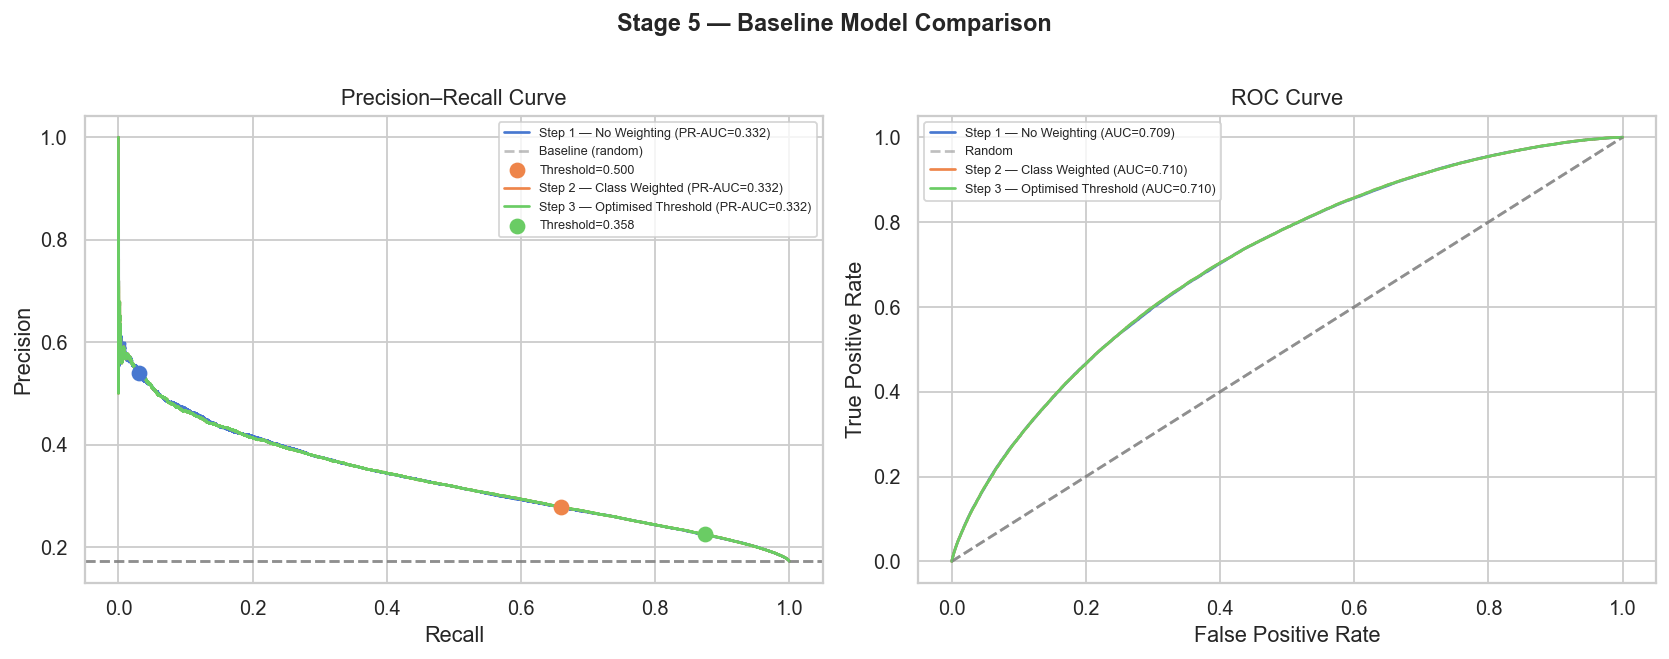

Saved: models/05_pr_roc_curves.png


In [24]:
# ── Plot PR and ROC curves for all three steps ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

curve_data = [
    (y_prob_step1, results_step1['threshold'], 'Step 1 — No Weighting'),
    (y_prob_step2, results_step2['threshold'], 'Step 2 — Class Weighted'),
    (y_prob_step2, optimal_threshold,          'Step 3 — Optimised Threshold'),
]

for y_prob, thresh, label in curve_data:
    plot_pr_roc_curves(y_test, y_prob, thresh, label, axes[0], axes[1])

# Deduplicate legend entries on ROC (Steps 2 and 3 share same probabilities)
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=7)

plt.suptitle('Stage 5 — Baseline Model Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(MODELS_DIR / '05_pr_roc_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: models/05_pr_roc_curves.png')

### Interpretation — PR and ROC Curves

**PR Curve (left):**
- The area under this curve (PR-AUC) is your primary model quality signal for
  imbalanced classification. A higher curve = better minority-class performance
- Steps 2 and 3 share the same PR curve shape (same model); Step 3 simply
  operates at a different point on the curve, marked by the dot
- The operating point for Step 3 should sit in the region of high Recall with
  acceptable Precision — visually in the upper-right portion of the curve
- If Step 1's PR curve sits substantially below Steps 2/3, the class weighting
  genuinely changed the model's minority-class calibration — not just the threshold

**ROC Curve (right):**
- This curve will look similar for all three steps — ROC-AUC measures overall
  rank-ordering ability, which class weighting does not dramatically change
- A strong ROC-AUC (≥ 0.80) with a weak PR-AUC is common for imbalanced
  problems and is exactly why we track both

**The gap between the PR curve and the baseline (dashed horizontal line) is
the visual summary of how much value the model adds over a random policy.**

---
## 8. Feature Importance — Step 2 Model

XGBoost's built-in feature importance plots the number of times each feature
was used to split a node across all trees (`weight`), the average gain from
splits using that feature (`gain`), or the fractional coverage of training
examples (`cover`).

We plot **gain** — it is the most informative measure because it directly
quantifies how much each feature improved the model's objective when used
as a split. High-gain features are genuinely useful; high-weight but
low-gain features may be noise splits.

**Note:** This is XGBoost's internal importance, which can be unreliable for
correlated features (it may arbitrarily assign credit to one over another).
Stage 7 replaces this with SHAP — a theoretically grounded method. Use this
plot as a directional signal, not the final importance ranking.

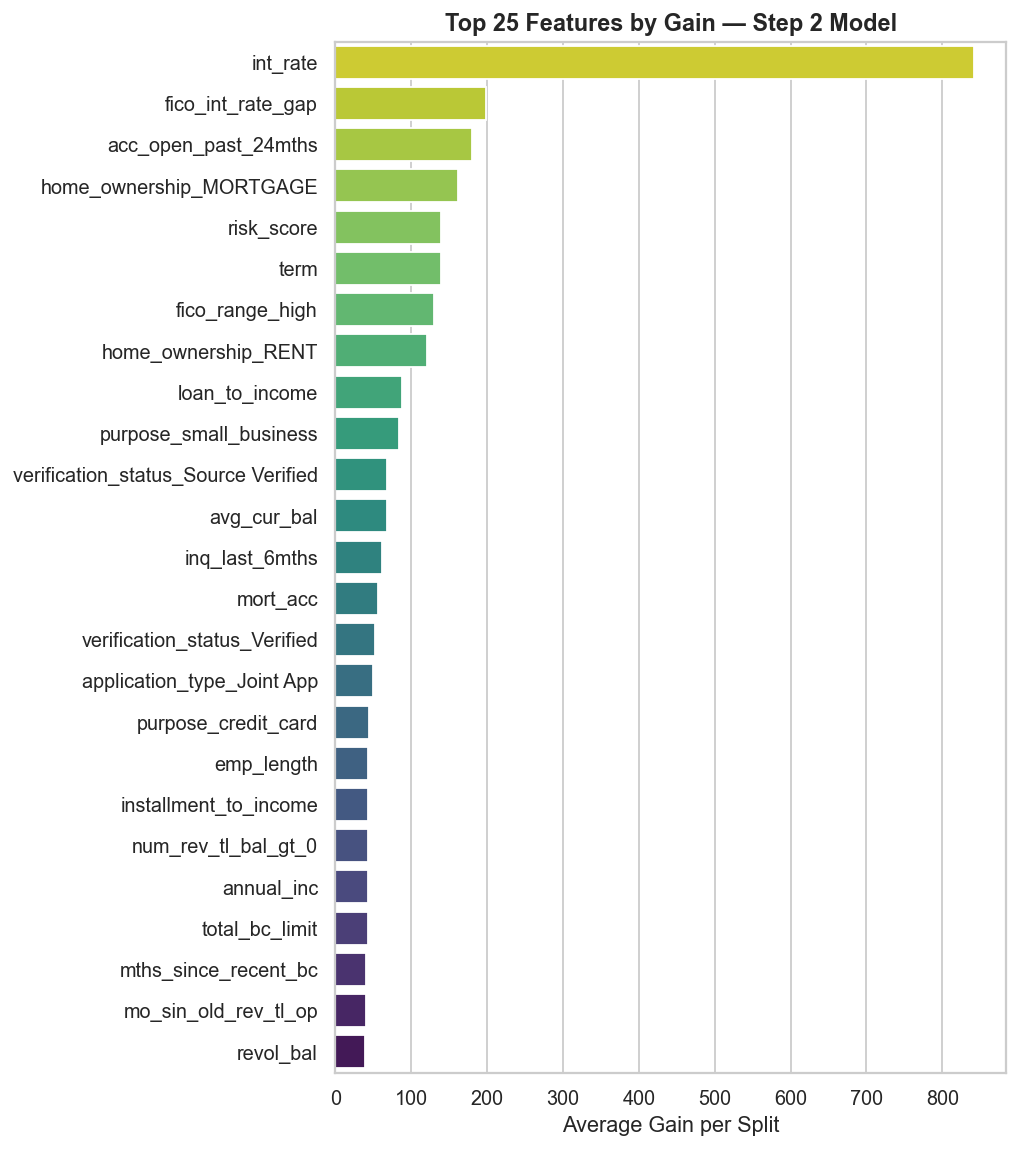

Top 10 features by gain:
                feature     gain
               int_rate 842.0592
      fico_int_rate_gap 199.2455
   acc_open_past_24mths 180.7590
home_ownership_MORTGAGE 161.7124
             risk_score 139.8117
                   term 139.1325
        fico_range_high 130.2145
    home_ownership_RENT 121.2979
         loan_to_income  87.7833
 purpose_small_business  84.4516


In [26]:
# ── Feature importance (gain) — Step 2 model ─────────────────────────────────
importance_dict = model_step2.get_booster().get_score(importance_type='gain')
importance_df   = (
    pd.DataFrame(importance_dict.items(), columns=['feature', 'gain'])
    .sort_values('gain', ascending=False)
    .reset_index(drop=True)
)

top_n = 25

fig, ax = plt.subplots(figsize=(8, 9))
sns.barplot(
    data=importance_df.head(top_n),
    x='gain', y='feature',
    palette='viridis_r',
    ax=ax
)
ax.set_title(f'Top {top_n} Features by Gain — Step 2 Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Gain per Split')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(MODELS_DIR / '05_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Top 10 features by gain:')
print(importance_df.head(10).to_string(index=False))

### Interpretation — Feature Importance

**Expected top features:**
- `int_rate` — the single strongest predictor from Stage 1 (Cohen's d = 0.62)
  should appear near the top; it is the lender's own risk assessment
- `fico_int_rate_gap` — if this ranks above `int_rate` alone, the gap feature
  is capturing something the raw rate misses. If they are close, monitor for
  importance splitting (flagged in Stage 4 notes)
- `risk_score` — composite feature; may absorb importance from its components
  (`int_rate`, `dti`, `fico`). If it ranks very high, the composite is working
- `fico_range_high` — second-ranked in Stage 1 (d = 0.40)
- `dti` — should appear in top 10

**Key flags to check:**
- If `fico_int_rate_gap` and `int_rate` are both in the top 5 with similar gain
  → they are splitting importance; note for Stage 7 SHAP investigation
- If any obviously weak features appear near the top → worth revisiting in Stage 6
- If `credit_age_months` or the ratio features appear in the top 15
  → the engineered features added genuine signal

This is a directional check only. SHAP in Stage 7 gives the definitive ranking.

---
## 9. Confusion Matrix — Step 3 (Operating Model)

The confusion matrix translates the abstract Recall/Precision numbers into
concrete loan counts. This is the business-facing view of model performance —
how many defaults does the model catch? How many good loans does it wrongly flag?

We plot Step 3 (the optimised-threshold model) as it represents our best
current performance and the configuration we would actually operate.

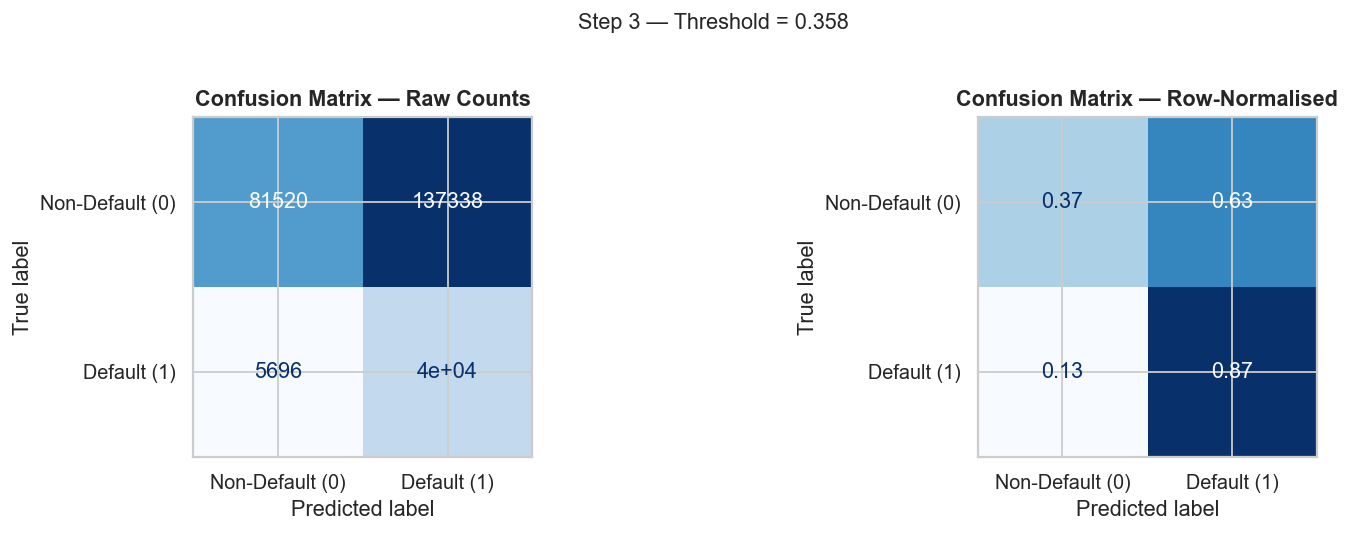

TRUE NEGATIVES  (correct non-default):     81,520  (37.2% of non-defaults)
FALSE POSITIVES (flagged, not default):    137,338  (62.8% of non-defaults)
FALSE NEGATIVES (missed defaults):           5,696  (12.5% of true defaults)
TRUE POSITIVES  (caught defaults):          39,816  (87.5% of true defaults)

Of 45,512 actual defaults in test set:
  Model caught : 39,816 (87.5%)
  Model missed : 5,696 (12.5%)


In [27]:
# ── Confusion matrix — Step 3 operating model ────────────────────────────────
y_pred_step3 = (y_prob_step2 >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_step3)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw counts
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Default (0)', 'Default (1)']
)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')

# Normalised by true label (shows Recall and FNR directly)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2   = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['Non-Default (0)', 'Default (1)']
)
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — Row-Normalised', fontweight='bold')

plt.suptitle(f'Step 3 — Threshold = {optimal_threshold:.3f}', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(MODELS_DIR / '05_confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'TRUE NEGATIVES  (correct non-default): {tn:>10,}  ({tn/(tn+fp)*100:.1f}% of non-defaults)')
print(f'FALSE POSITIVES (flagged, not default): {fp:>10,}  ({fp/(tn+fp)*100:.1f}% of non-defaults)')
print(f'FALSE NEGATIVES (missed defaults):      {fn:>10,}  ({fn/(fn+tp)*100:.1f}% of true defaults)')
print(f'TRUE POSITIVES  (caught defaults):      {tp:>10,}  ({tp/(fn+tp)*100:.1f}% of true defaults)')
print()
print(f'Of {fn+tp:,} actual defaults in test set:')
print(f'  Model caught : {tp:,} ({tp/(fn+tp)*100:.1f}%)')
print(f'  Model missed : {fn:,} ({fn/(fn+tp)*100:.1f}%)')

### Interpretation — Confusion Matrix

**How to read this:**
- **True Positives (bottom-right)** — defaults the model correctly flagged.
  These are the loans the bank can decline or price higher, avoiding principal loss
- **False Negatives (bottom-left)** — defaults the model missed. These are the
  most costly errors; each one represents a loan that was approved and subsequently
  defaulted. Stage 0 estimated FN:FP cost ratio at ~4.6x
- **False Positives (top-right)** — good loans the model flagged. Each one is a
  missed revenue opportunity, but not a direct loss
- **True Negatives (top-left)** — good loans correctly approved. The bulk of
  the portfolio

**The normalised matrix (right)** shows the row-level rates directly: the
bottom-right value is the model's Recall (fraction of defaults caught).

**Business translation:** If Recall is, say, 0.78 with a test set of ~45,000
defaults, the model catches ~35,000 and misses ~10,000. Those 10,000 missed
defaults — multiplied by average loan size — represent the portfolio loss
this model cannot yet prevent. Stage 6 tuning reduces that number.

---
## 10. Save Results & Artifacts

Persist the full metrics table and the Step 3 model to disk. Stage 6 will
load Step 2 as the starting point for hyperparameter tuning.

In [28]:
# ── Save full results table ────────────────────────────────────────────────────
with open(MODELS_DIR / '05_baseline_results.json', 'w') as f:
    json.dump(results_all, f, indent=2)

print(f'Saved: {MODELS_DIR / "05_baseline_results.json"}')

Saved: models/05_baseline_results.json


In [29]:
# ── Step 3 = Step 2 model + saved threshold — alias it for explicitness ───────
joblib.dump(model_step2, MODELS_DIR / '05_baseline_step3.joblib')
print(f'Saved: {MODELS_DIR / "05_baseline_step3.joblib"}')
print(f'Note: Step 3 = Step 2 model weights + threshold = {optimal_threshold:.4f}')

Saved: models/05_baseline_step3.joblib
Note: Step 3 = Step 2 model weights + threshold = 0.3584


---
## 11. Final Sanity Check

In [30]:
# ── Verify all artifacts saved ────────────────────────────────────────────────
expected_files = [
    MODELS_DIR / '05_baseline_step1.joblib',
    MODELS_DIR / '05_baseline_step2.joblib',
    MODELS_DIR / '05_baseline_step3.joblib',
    MODELS_DIR / '05_threshold.json',
    MODELS_DIR / '05_baseline_results.json',
    MODELS_DIR / '05_pr_roc_curves.png',
    MODELS_DIR / '05_confusion_matrix.png',
    MODELS_DIR / '05_feature_importance.png',
]

print('=' * 60)
print('  STAGE 5 — FINAL SANITY CHECK')
print('=' * 60)
print(f'  X_train shape          : {X_train.shape}')
print(f'  X_test shape           : {X_test.shape}')
print(f'  Residual nulls (train) : {X_train.isnull().sum().sum()}')
print(f'  Residual nulls (test)  : {X_test.isnull().sum().sum()}')
print()
print(f'  Step 1 best iteration  : {model_step1.best_iteration}')
print(f'  Step 2 best iteration  : {model_step2.best_iteration}')
print(f'  Optimal threshold      : {optimal_threshold:.4f}')
print()
print(f'  ROC-AUC  (Step 3)      : {results_step3["roc_auc"]:.4f}  | target ≥ 0.80')
print(f'  PR-AUC   (Step 3)      : {results_step3["pr_auc"]:.4f}  | target ≥ 0.70')
print(f'  Recall   (Step 3)      : {results_step3["recall"]:.4f}  | target ≥ 0.75')
print(f'  Precision(Step 3)      : {results_step3["precision"]:.4f}')
print()
print('  Artifacts:')
all_saved = True
for fpath in expected_files:
    exists = fpath.exists()
    print(f'    {"✓" if exists else "✗ MISSING"} {fpath}')
    if not exists:
        all_saved = False

print()
if all_saved:
    print('✅ Stage 5 complete. All artifacts saved. Ready for Stage 6 tuning.')
else:
    print('⚠️  One or more artifacts are missing — check cells above.')
print('=' * 60)

  STAGE 5 — FINAL SANITY CHECK
  X_train shape          : (1057477, 70)
  X_test shape           : (264370, 70)
  Residual nulls (train) : 0
  Residual nulls (test)  : 0

  Step 1 best iteration  : 187
  Step 2 best iteration  : 240
  Optimal threshold      : 0.3584

  ROC-AUC  (Step 3)      : 0.7099  | target ≥ 0.80
  PR-AUC   (Step 3)      : 0.3317  | target ≥ 0.70
  Recall   (Step 3)      : 0.8748  | target ≥ 0.75
  Precision(Step 3)      : 0.2248

  Artifacts:
    ✓ models/05_baseline_step1.joblib
    ✓ models/05_baseline_step2.joblib
    ✓ models/05_baseline_step3.joblib
    ✓ models/05_threshold.json
    ✓ models/05_baseline_results.json
    ✓ models/05_pr_roc_curves.png
    ✓ models/05_confusion_matrix.png
    ✓ models/05_feature_importance.png

✅ Stage 5 complete. All artifacts saved. Ready for Stage 6 tuning.


---
## Stage 5 — Summary & Handoff to Stage 6

### What was done

Three baseline experiments isolated the contribution of each imbalance correction:

| Step | Change | Purpose |
|---|---|---|
| 1 | No correction | Honest benchmark — raw imbalance impact |
| 2 | `scale_pos_weight = 4.8` | Isolate class weighting contribution |
| 3 | + Threshold optimised on F2 | Best achievable without hyperparameter tuning |

---

### Handoff to Stage 6 — Hyperparameter Tuning

Stage 6 uses **Optuna** to run a Bayesian search over XGBoost hyperparameters.
The starting point is the Step 2 model configuration (class weighting kept;
threshold optimisation is re-applied after tuning).

**Primary search space for Stage 6:**

| Parameter | Range | Rationale |
|---|---|---|
| `n_estimators` | 200–1000 | More trees + lower LR often helps |
| `max_depth` | 3–8 | Controls overfitting |
| `learning_rate` | 0.01–0.2 | Lower rate + more trees is usually better |
| `min_child_weight` | 1–10 | Stronger regularisation for minority class |
| `subsample` | 0.6–1.0 | Row sampling — reduces variance |
| `colsample_bytree` | 0.6–1.0 | Column sampling — reduces variance |
| `gamma` | 0–5 | Minimum loss reduction to split — pruning |
| `reg_alpha` | 0–2 | L1 regularisation |
| `reg_lambda` | 0–5 | L2 regularisation |

**Objective for Optuna:** maximise PR-AUC on a stratified 20% held-out
validation split from the training set.

**Keep fixed in Stage 6:** `scale_pos_weight = 4.8`, `tree_method = 'hist'`,
`eval_metric = 'aucpr'`.

**Targets to beat (Stage 5 best → Stage 6 target):**
- ROC-AUC: current → ≥ 0.85 stretch
- Recall:  current → ≥ 0.80 stretch
- PR-AUC:  current → ≥ 0.75 stretch